# 09 胴体指令とゲイト指令を分ける（フェーズ 1）

## 背景

LC は「THE GAIT AND THE GOAL ARE COMPLETELY DIFFERENT AND SEPARATED」である（[legged_control/00](../docs/legged_control/00_README.md)）。この段の新しい現象は **入力が二つ** になること。脚力の中身は 08 の `plan_grf` のまま。NMPC も WBC もまだ無い。

### 成功条件

| 量 | 条件 |
|---|---|
| 入力 | `BodyCommand` と `GaitCommand` が別オブジェクト。互いに import しない |
| ゲイト \(c\) | `GaitCommand` だけから作る |
| \(F_x,z^{ref}\) | `BodyCommand` だけから `plan_grf` の ref へ |
| hold / 末尾 5 s | \(\ge 5.0\,\mathrm{s}\)、\(z>0.20\,\mathrm{m}\)、\(\lvert\mathrm{roll}\rvert,\lvert\mathrm{pitch}\rvert<0.35\,\mathrm{rad}\) |
| GIF | 指令 GRF |

## 数式

```text
c   = gait(GaitCommand, t)
grf = plan_grf(x, c, schedule=None, ref=body_to_ref(BodyCommand, z))
```

## 仮説

分けても 08 と同じ 5 秒が残る。


In [1]:

from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

HOLD_S = 5.0
ATT_TOL = 0.35
Z_MIN = 0.20
T_RUN = 7.0
KP_SW, KD_SW, STEP_H = 300.0, 20.0, 0.02
KP_Z, KD_Z = 8000.0, 400.0
FX_TINY = 0.6

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: 01 の飽和。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def jac_leg(model, data, geoms, i):
    """内容: 脚 i の 3x3 足ヤコビ。"""
    J = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, J, None, int(geoms[i]))
    return J[:, 6 + 3 * i : 9 + 3 * i]

def plan_grf(x, flags, schedule, ref):
    """内容: 08 の契約。x=(z,vz,mass), flags=c, ref=(zref,fx_tot)。戻り (4,3)。"""
    c = np.asarray(flags, dtype=np.float64).reshape(4)
    ns = max(float(c.sum()), 1.0)
    z, vz, mass = float(x[0]), float(x[1]), float(x[2])
    zref, fx_tot = float(ref[0]), float(ref[1])
    fz_tot = mass * 9.81 + KP_Z * (zref - z) - KD_Z * vz
    grf = np.zeros((4, 3), dtype=np.float64)
    for i in range(4):
        if c[i] > 0.5:
            grf[i, 0] = fx_tot / ns
            grf[i, 2] = fz_tot / ns
    return grf

from dataclasses import dataclass

@dataclass(frozen=True)
class BodyCommand:
    """意図: LC の cmd_vel 側。ゲイトを持たない。"""
    z_offset: float = 0.0  # 内容: 目標高さは z0 + この値 [m]
    fx_tot: float = FX_TINY  # 内容: 07 の微小前進力 [N]

@dataclass(frozen=True)
class GaitCommand:
    """意図: LC の gait 指令側。胴体速度を持たない。"""
    freq: float = 1.0
    duty: float = 0.98
    offset: np.ndarray = None  # 内容: 下で trot を入れる

    def __post_init__(self):
        object.__setattr__(self, "offset", np.array([0.5, 1.0, 1.0, 0.5]) if self.offset is None else np.asarray(self.offset, dtype=float))

body = BodyCommand()  # 内容: 胴体枝
gait = GaitCommand()  # 内容: ゲイト枝。混ぜない
print("split", body, gait)

def rollout(body, gait):
    """内容: c は gait だけ、ref は body だけ。"""
    p = MujocoGo2(scene="flat", seed=0)
    dt = p.sim_dt
    n = int(round(T_RUN / dt))
    geoms = p.foot_geom_ids()
    z0 = float(p.base_pos()[2])
    phi = gait.offset.copy()
    lift = p.feet_pos_world().copy()
    prev = np.ones(4)
    ok = []
    last = np.zeros((4, 3))
    for _k in range(n):
        phi = (phi + dt * gait.freq) % 1.0
        c = (phi < gait.duty).astype(float)  # 内容: BodyCommand を見ない
        z = float(p.base_pos()[2])
        vz = float(p.base_lin_vel_world()[2])
        ref = np.array([z0 + body.z_offset, body.fx_tot])  # 内容: GaitCommand を見ない
        grf = plan_grf(np.array([z, vz, p.mass_kg]), c, None, ref)
        last = grf
        feet = p.feet_pos_world()
        vel = p.feet_vel_world()
        h = np.asarray(p.data.qfrc_bias[6:], dtype=np.float64)
        tau = np.zeros(12)
        for i in range(4):
            if prev[i] > 0.5 and c[i] < 0.5:
                lift[i] = feet[i].copy()
            Jleg = jac_leg(p.model, p.data, geoms, i)
            sl = slice(3 * i, 3 * i + 3)
            if c[i] > 0.5:
                tau[sl] = h[sl] - Jleg.T @ grf[i]
            else:
                s = float(np.clip((phi[i] - gait.duty) / max(1e-6, 1.0 - gait.duty), 0.0, 1.0))
                w = gait.freq / max(1e-6, 1.0 - gait.duty)
                p_d = lift[i].copy()
                p_d[2] = lift[i, 2] + STEP_H * np.sin(np.pi * s)
                v_d = np.zeros(3)
                v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
                tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
        p.step(clip_torque(tau, p.model.actuator_ctrlrange))
        prev = c
        rpy = p.base_rpy()
        z = float(p.base_pos()[2])
        ok.append(abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL and z > Z_MIN and bool(np.isfinite(p.data.qpos).all()))
    n5 = int(round(HOLD_S / dt))
    return {"hold": longest_true_seconds(ok, dt), "last5": bool(all(ok[-n5:])), "last": last, "n": n, "dt": dt}

r = rollout(body, gait)
print("hold", r["hold"], "last5", r["last5"])
assert r["hold"] >= HOLD_S and r["last5"]
print("09 PASS: split commands held", r["hold"], "s")


split BodyCommand(z_offset=0.0, fx_tot=0.6) GaitCommand(freq=1.0, duty=0.98, offset=array([0.5, 1. , 1. , 0.5]))


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


hold 7.0 last5 True
09 PASS: split commands held 7.0 s


/home/takuya/work/mpc_dog/notebook/assets/09_cmd_split.gif 1966065 bytes


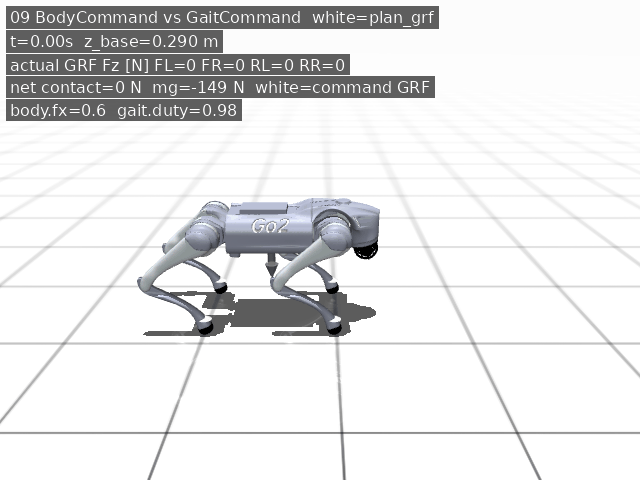

In [2]:

# --- このセルの意図 ---
# GIF。caption に body / gait を別表示する。

st = {"phi": gait.offset.copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3))}

def tau_fn(pl):
    """内容: 上と同じ分岐。"""
    dt = pl.sim_dt
    if st["lift"] is None:
        st["lift"] = pl.feet_pos_world().copy()
        st["z0"] = float(pl.base_pos()[2])
    geoms = pl.foot_geom_ids()
    phi = (st["phi"] + dt * gait.freq) % 1.0
    c = (phi < gait.duty).astype(float)
    z = float(pl.base_pos()[2])
    vz = float(pl.base_lin_vel_world()[2])
    grf = plan_grf(np.array([z, vz, pl.mass_kg]), c, None, np.array([st["z0"] + body.z_offset, body.fx_tot]))
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    for i in range(4):
        if st["prev"][i] > 0.5 and c[i] < 0.5:
            st["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        if c[i] > 0.5:
            tau[sl] = h[sl] - Jleg.T @ grf[i]
        else:
            s = float(np.clip((phi[i] - gait.duty) / max(1e-6, 1.0 - gait.duty), 0.0, 1.0))
            w = gait.freq / max(1e-6, 1.0 - gait.duty)
            p_d = st["lift"][i].copy()
            p_d[2] = st["lift"][i, 2] + STEP_H * np.sin(np.pi * s)
            v_d = np.zeros(3)
            v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
            tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
    st["phi"] = phi
    st["prev"] = c
    st["cmd"] = grf
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant = MujocoGo2(scene="flat", seed=0)
path = render_rollout_gif(
    plant,
    Path("assets/09_cmd_split.gif"),
    n_steps=int(round(T_RUN / plant.sim_dt)),
    capture_every=80,
    tau_fn=tau_fn,
    command_grf=lambda pl: st["cmd"],
    extra_lines=lambda pl: [f"body.fx={body.fx_tot}  gait.duty={gait.duty}"],
    title="09 BodyCommand vs GaitCommand  white=plan_grf",
)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 分析

胴体とゲイトを別オブジェクトにしても 5 秒持つ。GIF `09_cmd_split.gif`。次は並進の線形 KF。真値ソースは残す。
